<a href="https://colab.research.google.com/github/S-0120/XAI/blob/main/XAI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [4]:
DATASET_PATH = '/content/drive/MyDrive/datasets/CICMalDroid.xlsx'

df = pd.read_excel(DATASET_PATH)
print(f"Dataset loaded! Shape: {df.shape}")
df.head()

Dataset loaded! Shape: (11598, 471)


,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,utimes,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev,Class
0,1,0,0,3,0,14,2,0,3,0,...,0,0,0,0,0,0,0,37,10,1
1,3,0,0,6,0,42,91,0,32,0,...,0,0,0,0,0,0,2,2838,46,1
2,2,0,0,4,0,23,3,0,17,2,...,0,0,0,0,0,0,1,111,20,1
3,1,0,0,4,0,27,9,0,36,0,...,0,0,0,0,0,0,7,987,197,1
4,3,0,0,11,0,18,3,0,16,0,...,0,0,0,0,0,0,1,98,25,1


In [5]:
print(df.columns.tolist())

['ACCESS_PERSONAL_INFO___', 'ALTER_PHONE_STATE___', 'ANTI_DEBUG_____', 'CREATE_FOLDER_____', 'CREATE_PROCESS`_____', 'CREATE_THREAD_____', 'DEVICE_ACCESS_____', 'EXECUTE_____', 'FS_ACCESS____', 'FS_ACCESS()____', 'FS_ACCESS(CREATE)____', 'FS_ACCESS(CREATE__APPEND)__', 'FS_ACCESS(CREATE__READ)__', 'FS_ACCESS(CREATE__READ__WRITE)', 'FS_ACCESS(CREATE__WRITE)__', 'FS_ACCESS(CREATE__WRITE__APPEND)', 'FS_ACCESS(READ)____', 'FS_ACCESS(READ__WRITE)__', 'FS_ACCESS(WRITE)____', 'FS_PIPE_ACCESS___', 'FS_PIPE_ACCESS()___', 'FS_PIPE_ACCESS(READ)___', 'FS_PIPE_ACCESS(READ__)_', 'FS_PIPE_ACCESS(READ__WRITE)_', 'FS_PIPE_ACCESS(WRITE)___', 'NETWORK_ACCESS____', 'NETWORK_ACCESS()____', 'NETWORK_ACCESS(READ)____', 'NETWORK_ACCESS(READ__WRITE)__', 'NETWORK_ACCESS(READ__WRITE__)', 'NETWORK_ACCESS(WRITE)____', 'NETWORK_ACCESS(WRITE__)__', 'SMS_SEND____', 'TERMINATE_PROCESS', 'TERMINATE_THREAD', '__arm_nr_cacheflush', '__arm_nr_set_tls', '_llseek', '_newselect', 'accept', 'access', 'add', 'addAccessibilityIn

In [6]:
print("=== Class Distribution ===")
print(df['Class'].value_counts())
print()

print("=== Null Values ===")
print(df.isnull().sum().sum(), "total null values")

print("\n=== Data Types ===")
print(df.dtypes.value_counts())

print(f"\nFeatures: {df.shape[1] - 1}")
print(f"Samples:  {df.shape[0]}")

=== Class Distribution ===
Class
3    3904
4    2546
2    2100
5    1795
1    1253
Name: count, dtype: int64

=== Null Values ===
0 total null values

=== Data Types ===
int64    471
Name: count, dtype: int64

Features: 470
Samples:  11598


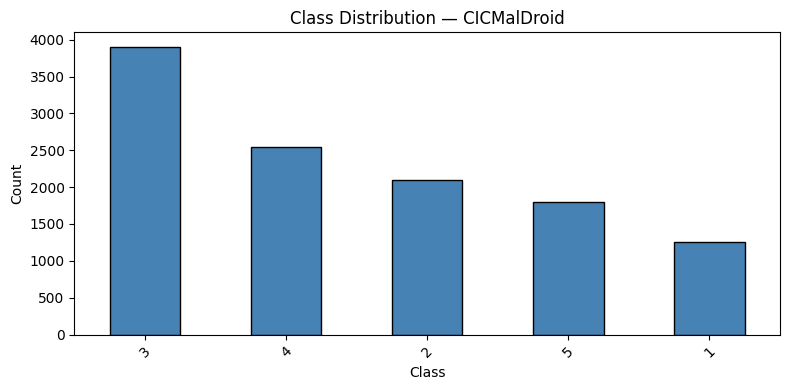

In [7]:
plt.figure(figsize=(8, 4))
df['Class'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution — CICMalDroid')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

print(f"Null values before: {df.isnull().sum().sum()}")
df.dropna(inplace=True)
print(f"Null values after:  {df.isnull().sum().sum()}")
print(f"Shape after cleaning: {df.shape}")

Null values before: 0
Null values after:  0
Shape after cleaning: (11598, 471)


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['class_encoded'] = le.fit_transform(df['Class'])

print("Class mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

Class mapping:
  1 → 0
  2 → 1
  3 → 2
  4 → 3
  5 → 4


In [10]:
X = df.drop(columns=['Class', 'class_encoded'])
y = df['class_encoded']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")

Features shape: (11598, 470)
Target shape:   (11598,)


Class counts: Counter({2: 3904, 3: 2546, 1: 2100, 4: 1795, 0: 1253})


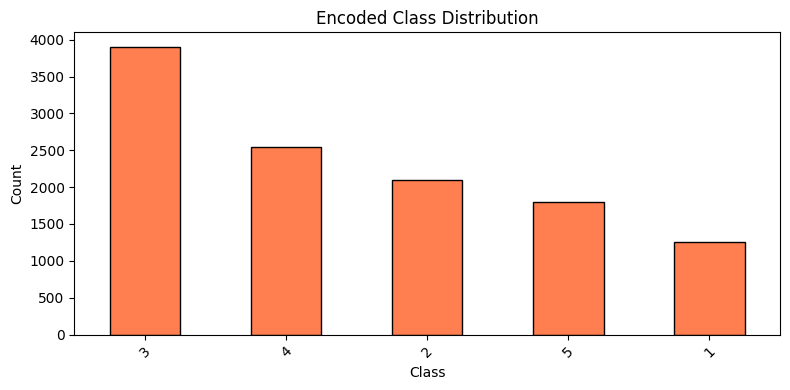

In [11]:
from collections import Counter

print("Class counts:", Counter(y))

plt.figure(figsize=(8, 4))
pd.Series(y).map(dict(enumerate(le.classes_))).value_counts().plot(
    kind='bar', color='coral', edgecolor='black'
)
plt.title('Encoded Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ensures same class ratio in both splits
)

print(f"Training set:   {X_train.shape}")
print(f"Test set:       {X_test.shape}")
print(f"\nTrain class dist: {Counter(y_train)}")
print(f"Test class dist:  {Counter(y_test)}")

Training set:   (9278, 470)
Test set:       (2320, 470)

Train class dist: Counter({2: 3123, 3: 2037, 1: 1680, 4: 1436, 0: 1002})
Test class dist:  Counter({2: 781, 3: 509, 1: 420, 4: 359, 0: 251})


In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {Counter(y_train)}")
print(f"After SMOTE:  {Counter(y_train_res)}")

Before SMOTE: Counter({2: 3123, 3: 2037, 1: 1680, 4: 1436, 0: 1002})
After SMOTE:  Counter({2: 3123, 1: 3123, 0: 3123, 3: 3123, 4: 3123})


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)   # fit ONLY on training data
X_test_scaled  = scaler.transform(X_test)             # transform test using same scaler

print("Scaling done!")
print(f"Train shape: {X_train_scaled.shape}")
print(f"Test shape:  {X_test_scaled.shape}")

Scaling done!
Train shape: (15615, 470)
Test shape:  (2320, 470)


In [15]:
import os

SAVE_PATH = '/content/drive/MyDrive/XAI/datasets/preprocessed/'
os.makedirs(SAVE_PATH, exist_ok=True)

np.save(SAVE_PATH + 'X_train.npy', X_train_scaled)
np.save(SAVE_PATH + 'X_test.npy',  X_test_scaled)
np.save(SAVE_PATH + 'y_train.npy', y_train_res)
np.save(SAVE_PATH + 'y_test.npy',  y_test)

print("Preprocessed data saved to Drive!")

Preprocessed data saved to Drive!


In [16]:
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

  0 → 1
  1 → 2
  2 → 3
  3 → 4
  4 → 5


In [17]:
print(df['Class'].value_counts())

Class
3    3904
4    2546
2    2100
5    1795
1    1253
Name: count, dtype: int64


## Preprocessing Summary — CICMalDroid (Android)

| Metric | Value |
|---|---|
| Total features | 470 |
| Original training samples | 9,278 |
| Original test samples | 2,320 |
| After SMOTE (train) | 15,615 |
| Classes | 5 |


### Class distribution (test set — untouched)
| Class | Count |
|---|---|
| 0 | 251 |
| 1 | 420 |
| 2 | 781 |
| 3 | 509 |
| 4 | 359 |
Train class dist: Counter({2: 3123, 3: 2037, 1: 1680, 4: 1436, 0: 1002})
Test class dist:  Counter({2: 781, 3: 509, 1: 420, 4: 359, 0: 251})


## Label Mapping — CICMalDroid

| Encoded | Original | Class |
|---|---|---|
| 0 | 1 | Adware |
| 1 | 2 | Banking malware |
| 2 | 3 | SMS malware |
| 3 | 4 | Riskware |
| 4 | 5 | Benign |

> Note: SMOTE balanced all classes to 3,123 training samples each.
> Test set remains untouched with original distribution.

In [18]:
from sklearn.feature_selection import mutual_info_classif
mi_scores = mutual_info_classif(X_train_scaled, y_train_res, random_state=42)
print("Done!")

Computing Mutual Information scores... (this may take a minute)
Done!


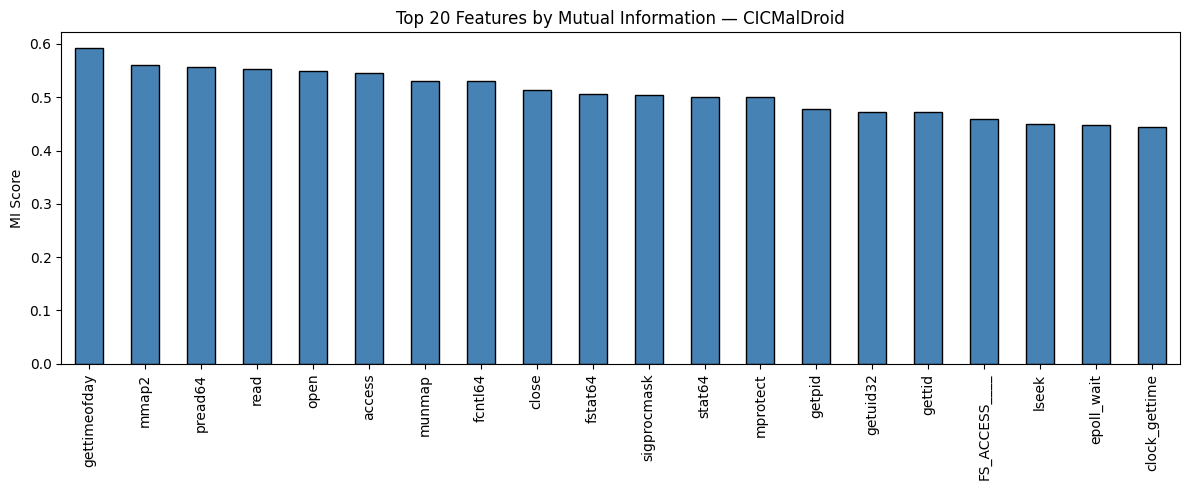


Top 20 feature names:
['gettimeofday', 'mmap2', 'pread64', 'read', 'open', 'access', 'munmap', 'fcntl64', 'close', 'fstat64', 'sigprocmask', 'stat64', 'mprotect', 'getpid', 'getuid32', 'gettid', 'FS_ACCESS____', 'lseek', 'epoll_wait', 'clock_gettime']


In [19]:
feature_names = X.columns.tolist()

# Create a series for easy sorting
mi_series = pd.Series(mi_scores, index=feature_names).sort_values(ascending=False)

# Plot top 20
plt.figure(figsize=(12, 5))
mi_series[:20].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 20 Features by Mutual Information — CICMalDroid')
plt.ylabel('MI Score')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("\nTop 20 feature names:")
print(mi_series[:20].index.tolist())

In [20]:
TOP_N = 100

top_features = mi_series[:TOP_N].index.tolist()

X_train_final = X_train_scaled[:, [feature_names.index(f) for f in top_features]]
X_test_final  = X_test_scaled[:,  [feature_names.index(f) for f in top_features]]

print(f"Reduced from 470 → {TOP_N} features")
print(f"Train shape: {X_train_final.shape}")
print(f"Test shape:  {X_test_final.shape}")

Reduced from 470 → 100 features
Train shape: (15615, 100)
Test shape:  (2320, 100)


In [21]:
import json, os

SAVE_PATH = '/content/drive/MyDrive/XAI/datasets/preprocessed/'
os.makedirs(SAVE_PATH, exist_ok=True)

np.save(SAVE_PATH + 'X_train_final.npy', X_train_final)
np.save(SAVE_PATH + 'X_test_final.npy',  X_test_final)
np.save(SAVE_PATH + 'y_train_final.npy', y_train_res)
np.save(SAVE_PATH + 'y_test_final.npy',  y_test)

with open(SAVE_PATH + 'top_feature_names.json', 'w') as f:
    json.dump(top_features, f)

print("All saved to Drive!")
print(f"Files saved: X_train_final, X_test_final, y_train_final, y_test_final, top_feature_names")

All saved to Drive!
Files saved: X_train_final, X_test_final, y_train_final, y_test_final, top_feature_names


In [22]:
X_train_check = np.load(SAVE_PATH + 'X_train_final.npy')
X_test_check  = np.load(SAVE_PATH + 'X_test_final.npy')
y_train_check = np.load(SAVE_PATH + 'y_train_final.npy')
y_test_check  = np.load(SAVE_PATH + 'y_test_final.npy')

print("=== Sanity Check ===")
print(f"X_train: {X_train_check.shape} → expect (15615, 100)")
print(f"X_test:  {X_test_check.shape}  → expect (2320, 100)")
print(f"y_train: {y_train_check.shape} → expect (15615,)")
print(f"y_test:  {y_test_check.shape}  → expect (2320,)")
print(f"\nClass balance in y_train: {Counter(y_train_check)}")

=== Sanity Check ===
X_train: (15615, 100) → expect (15615, 100)
X_test:  (2320, 100)  → expect (2320, 100)
y_train: (15615,) → expect (15615,)
y_test:  (2320,)  → expect (2320,)

Class balance in y_train: Counter({np.int64(2): 3123, np.int64(1): 3123, np.int64(0): 3123, np.int64(3): 3123, np.int64(4): 3123})


The top features are all Linux system calls — gettimeofday, mmap2, read, open, close etc. Because Android apps run on a Linux kernel and their malicious behaviour shows up in how they make system calls. 'gettimeofday' being the most informative suggests malware uses timing-based evasion techniques.

## **BASELINE MODEL TRAINING**



In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_final, y_train_res)

rf_preds = rf_baseline.predict(X_test_final)

print("=== Random Forest Baseline ===")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=['Adware','Banking','SMS','Riskware','Benign']))

=== Random Forest Baseline ===
Accuracy: 0.9461

Classification Report:
              precision    recall  f1-score   support

      Adware       0.85      0.94      0.89       251
     Banking       0.96      0.91      0.93       420
         SMS       0.98      0.99      0.98       781
    Riskware       0.96      0.91      0.94       509
      Benign       0.90      0.95      0.93       359

    accuracy                           0.95      2320
   macro avg       0.93      0.94      0.94      2320
weighted avg       0.95      0.95      0.95      2320



In [24]:
from xgboost import XGBClassifier

xgb_baseline = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_baseline.fit(X_train_final, y_train_res)

xgb_preds = xgb_baseline.predict(X_test_final)

print("=== XGBoost Baseline ===")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds, target_names=['Adware','Banking','SMS','Riskware','Benign']))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:27:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost Baseline ===
Accuracy: 0.9504

Classification Report:
              precision    recall  f1-score   support

      Adware       0.88      0.93      0.90       251
     Banking       0.95      0.92      0.93       420
         SMS       0.98      0.99      0.99       781
    Riskware       0.96      0.93      0.94       509
      Benign       0.92      0.96      0.94       359

    accuracy                           0.95      2320
   macro avg       0.94      0.94      0.94      2320
weighted avg       0.95      0.95      0.95      2320



=== Baseline Comparison ===
  Random Forest: 0.9461 [BELOW TARGET]
  XGBoost: 0.9504 [PASS]


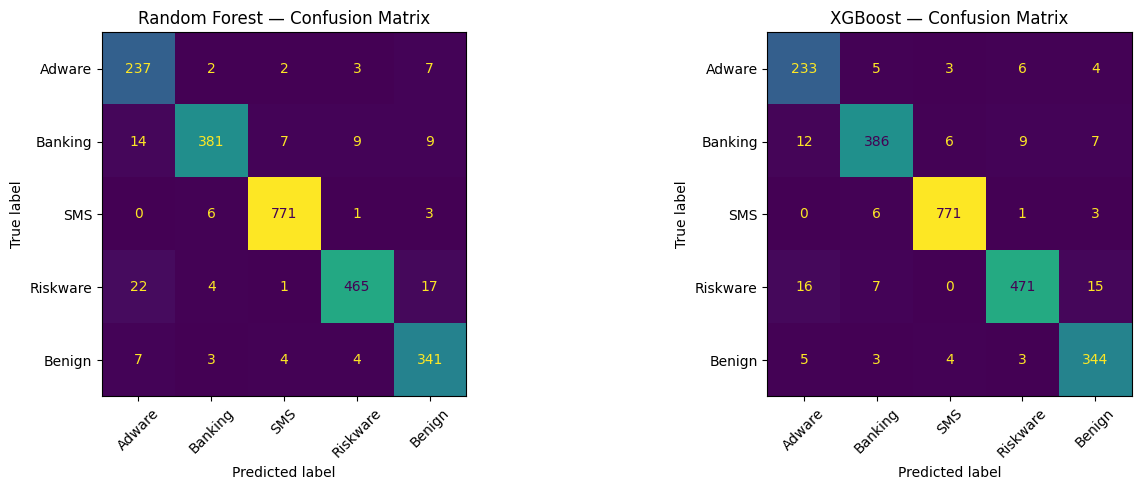

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

results = {
    'Random Forest': accuracy_score(y_test, rf_preds),
    'XGBoost':       accuracy_score(y_test, xgb_preds),
}

print("=== Baseline Comparison ===")
for model, acc in results.items():
    status = "PASS" if acc >= 0.95 else "BELOW TARGET"
    print(f"  {model}: {acc:.4f} [{status}]")

# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = ['Adware','Banking','SMS','Riskware','Benign']

for ax, preds, name in zip(axes, [rf_preds, xgb_preds], ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [26]:
import joblib

MODELS_PATH = '/content/drive/MyDrive/XAI/models/'
os.makedirs(MODELS_PATH, exist_ok=True)

joblib.dump(rf_baseline,  MODELS_PATH + 'rf_baseline.pkl')
joblib.dump(xgb_baseline, MODELS_PATH + 'xgb_baseline.pkl')

print("Baseline models saved!")

Baseline models saved!



Random Forest            94.61%          
XGBoost                  95.04%         

# **STACKING ENSEMBLE **

In [27]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from xgboost import XGBClassifier
import joblib

print("All imports ready!")

All imports ready!


In [28]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

svm = SVC(
    kernel='rbf',
    C=1.0,
    probability=True,   # needed for stacking to get class probabilities
    random_state=42
)

print("Base learners defined!")

Base learners defined!


In [29]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Generating out-of-fold predictions...")
print("RF...", end=" ")
rf_oof = cross_val_predict(rf, X_train_final, y_train_res,
                           cv=skf, method='predict_proba', n_jobs=-1)
print("done!")

print("XGBoost...", end=" ")
xgb_oof = cross_val_predict(xgb, X_train_final, y_train_res,
                            cv=skf, method='predict_proba', n_jobs=-1)
print("done!")

print("SVM...", end=" ")
svm_oof = cross_val_predict(svm, X_train_final, y_train_res,
                            cv=skf, method='predict_proba', n_jobs=-1)
print("done!")

print(f"\nOOF shapes — RF: {rf_oof.shape}, XGB: {xgb_oof.shape}, SVM: {svm_oof.shape}")

Generating out-of-fold predictions...
RF... done!
XGBoost... done!
SVM... done!

OOF shapes — RF: (15615, 5), XGB: (15615, 5), SVM: (15615, 5)


In [30]:
# Concatenate all OOF predictions — this becomes the training data for meta-learner
# Each model produces 5 probability columns (one per class), so 3 models = 15 meta-features
meta_train = np.hstack([rf_oof, xgb_oof, svm_oof])
print(f"Meta-train shape: {meta_train.shape} → expect (15615, 15)")

Meta-train shape: (15615, 15) → expect (15615, 15)


In [31]:
# Now train each base learner on full training data and predict on test set
print("Training base learners on full training data...")

print("RF...", end=" ")
rf.fit(X_train_final, y_train_res)
rf_test = rf.predict_proba(X_test_final)
print("done!")

print("XGBoost...", end=" ")
xgb.fit(X_train_final, y_train_res)
xgb_test = xgb.predict_proba(X_test_final)
print("done!")

print("SVM...", end=" ")
svm.fit(X_train_final, y_train_res)
svm_test = svm.predict_proba(X_test_final)
print("done!")

# Stack test predictions
meta_test_classical = np.hstack([rf_test, xgb_test, svm_test])
print(f"\nMeta-test shape (classical only): {meta_test_classical.shape} → expect (2320, 15)")

Training base learners on full training data...
RF... done!
XGBoost... done!
SVM... done!

Meta-test shape (classical only): (2320, 15) → expect (2320, 15)


In [32]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [33]:
# CNN expects 3D input: (samples, timesteps, features)
# We treat each of the 100 features as a timestep with 1 channel
X_train_cnn = X_train_final.reshape(-1, 100, 1)
X_test_cnn  = X_test_final.reshape(-1, 100, 1)

print(f"CNN Train shape: {X_train_cnn.shape} → expect (15615, 100, 1)")
print(f"CNN Test shape:  {X_test_cnn.shape}  → expect (2320, 100, 1)")

CNN Train shape: (15615, 100, 1) → expect (15615, 100, 1)
CNN Test shape:  (2320, 100, 1)  → expect (2320, 100, 1)


In [34]:
def build_cnn(input_shape, num_classes):
    model = keras.Sequential([
        # First conv block
        layers.Conv1D(filters=64, kernel_size=3, activation='relu',
                      input_shape=input_shape, padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        # Second conv block
        layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        # Third conv block
        layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dropout(0.3),

        # Dense head
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

cnn_model = build_cnn(input_shape=(100, 1), num_classes=5)
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 100, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 25, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,589 (232.77 KB)

 Trainable params: 59,077 (230.77 KB)

 Non-trainable params: 512 (2.00 KB)

In [35]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history = cnn_model.fit(
    X_train_cnn, y_train_res,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

print("CNN training complete!")

Epoch 1/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 37s 109ms/step - accuracy: 0.4445 - loss: 1.3663 - val_accuracy: 0.0019 - val_loss: 4.2905 - learning_rate: 0.0010
Epoch 2/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.6031 - loss: 1.0881 - val_accuracy: 0.0640 - val_loss: 3.9532 - learning_rate: 0.0010
Epoch 3/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.6683 - loss: 0.9180 - val_accuracy: 0.3656 - val_loss: 1.6406 - learning_rate: 0.0010
Epoch 4/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7037 - loss: 0.8182 - val_accuracy: 0.6300 - val_loss: 0.9622 - learning_rate: 0.0010
Epoch 5/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7296 - loss: 0.7566 - val_accuracy: 0.6985 - val_loss: 0.7923 - learning_rate: 0.0010
Epoch 6/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.7592 - loss: 0.6935 - val_accuracy: 0.5800 - val_loss: 1.2149 - learning_rate: 0.0010
Epoch 7/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.7702 - 

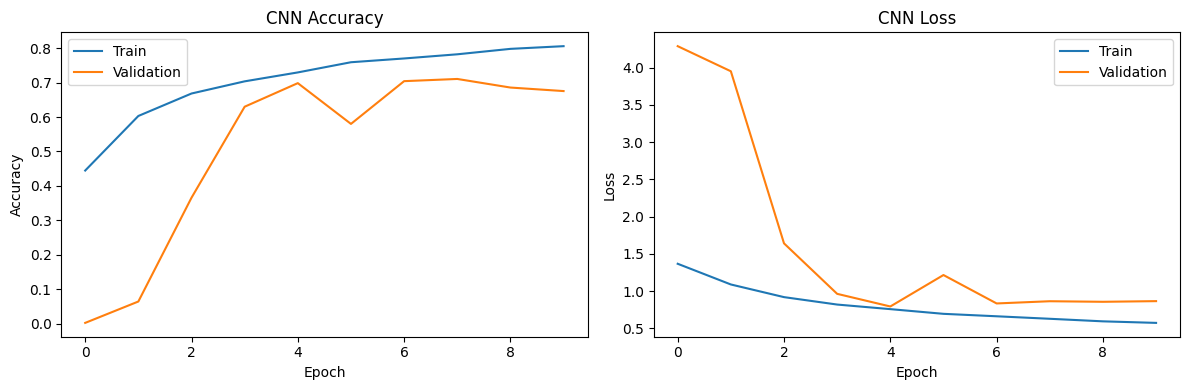

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('CNN Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('CNN Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [37]:
from sklearn.metrics import accuracy_score

cnn_preds_raw = cnn_model.predict(X_test_cnn)
cnn_preds     = np.argmax(cnn_preds_raw, axis=1)

print("=== CNN Baseline ===")
print(f"Accuracy: {accuracy_score(y_test, cnn_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, cnn_preds,
      target_names=['Adware','Banking','SMS','Riskware','Benign']))

73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step
=== CNN Baseline ===
Accuracy: 0.7892

Classification Report:
              precision    recall  f1-score   support

      Adware       0.57      0.77      0.66       251
     Banking       0.89      0.65      0.75       420
         SMS       0.86      0.97      0.91       781
    Riskware       0.79      0.67      0.73       509
      Benign       0.73      0.75      0.74       359

    accuracy                           0.79      2320
   macro avg       0.77      0.76      0.76      2320
weighted avg       0.80      0.79      0.79      2320



In [39]:
# Get CNN OOF predictions using manual k-fold
# (Keras models can't use cross_val_predict directly)
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cnn_oof = np.zeros((X_train_final.shape[0], 5))

print("Generating CNN out-of-fold predictions...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_final, y_train_res)):
    print(f"  Fold {fold+1}/5...", end=" ")

    X_fold_train = X_train_final[train_idx].reshape(-1, 100, 1)
    X_fold_val   = X_train_final[val_idx].reshape(-1, 100, 1)
    y_fold_train = y_train_res[train_idx]

    fold_model = build_cnn(input_shape=(100, 1), num_classes=5)
    fold_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    fold_model.fit(
        X_fold_train, y_fold_train,
        epochs=30,
        batch_size=64,
        validation_split=0.1,
        callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                                 restore_best_weights=True)],
        verbose=0
    )
    cnn_oof[val_idx] = fold_model.predict(X_fold_val, verbose=0)
    print("done!")

print(f"\nCNN OOF shape: {cnn_oof.shape} → expect (15615, 5)")

Generating CNN out-of-fold predictions...
  Fold 1/5... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


done!
  Fold 2/5... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


done!
  Fold 3/5... 

...

done!
  Fold 4/5... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


done!
  Fold 5/5... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


done!

CNN OOF shape: (15615, 5) → expect (15615, 5)


In [40]:
# Get CNN test predictions from the fully trained model
cnn_test = cnn_model.predict(X_test_cnn)

# Final meta-features: RF + XGB + SVM + CNN = 20 features
meta_train_full = np.hstack([meta_train, cnn_oof])
meta_test_full  = np.hstack([meta_test_classical, cnn_test])

print(f"Final meta-train shape: {meta_train_full.shape} → expect (15615, 20)")
print(f"Final meta-test shape:  {meta_test_full.shape}  → expect (2320, 20)")

# Save
np.save(MODELS_PATH + 'meta_train_full.npy', meta_train_full)
np.save(MODELS_PATH + 'meta_test_full.npy',  meta_test_full)
cnn_model.save(MODELS_PATH + 'cnn_base.h5')

print("All saved!")

73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
Final meta-train shape: (15615, 20) → expect (15615, 20)
Final meta-test shape:  (2320, 20)  → expect (2320, 20)


All saved!
